In [115]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import kagglehub
import missingno as msn
import pytimetk as tk
from IPython.display import display, HTML

# Modeling & Evaluation
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pipeline & Preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler

sns.set()

In [116]:
# 1. Download the dataset
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

# 2. Look for the Excel file in the downloaded path
file_path = os.path.join(path, "E Commerce Dataset.xlsx")

# 3. Load the 'E Comm' sheet (this is the raw data)
# Note: You may need to run 'pip install openpyxl' first
df = pd.read_excel(file_path, sheet_name='E Comm')


In [117]:
data= df.copy()

### EDA

In [118]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [119]:
print(f'shape: {df.shape}')
print(f'duplicates: {df.duplicated().sum()}')
print('Unique Keys:',len(df['CustomerID'].unique()))

shape: (5630, 20)
duplicates: 0
Unique Keys: 5630


In [120]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [121]:
print('Nb of empty rows:',df.isna().all(axis=1).sum())

Nb of empty rows: 0


In [122]:
#questions:
# what is the data about
# when was it collected, where, how
# can we fill na
# is it imbalance

In [123]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

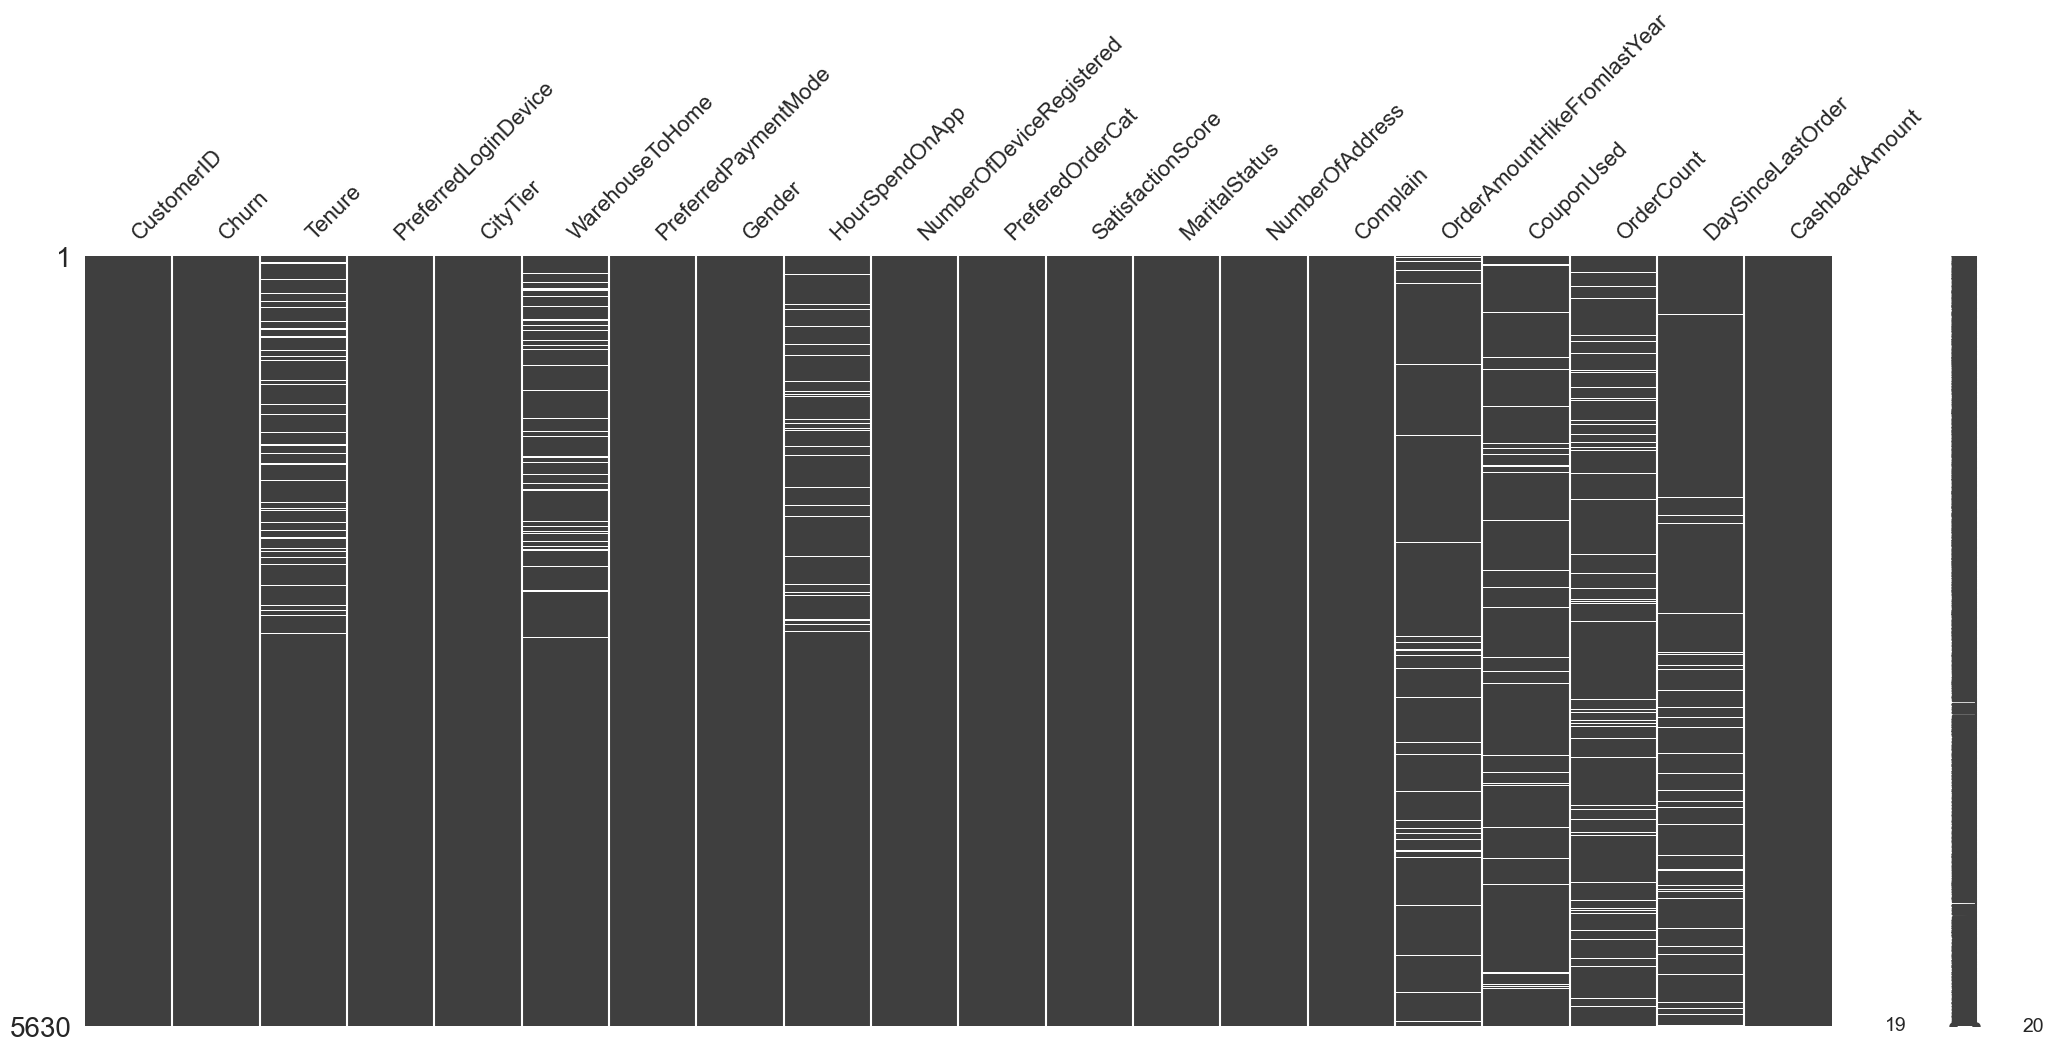

In [124]:
plt.figure()
msn.matrix(df)
plt.show()

### 1st approach: dropping na

In [125]:
df_clean1= df.dropna()

In [126]:
# Calculate counts and percentages
counts = df_clean1['Churn'].value_counts()
percent = df_clean1['Churn'].value_counts(normalize=True) * 100

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percent.round(2)
})

# Display as HTML table
display(HTML("<h3>Churn Distribution Summary</h3>"))
display(HTML(summary_df.to_html(classes='table table-striped')))

,Count,Percentage (%)
Churn,,
0,3143,83.28
1,631,16.72


In [127]:
df.dtypes.value_counts()

float64    8
int64      7
object     5
Name: count, dtype: int64

In [128]:
# Select only the specific columns you requested
target_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_objects = df[target_cols]

html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif; font-size: 0.9em;'>
<tr style='background-color: #2c3e50; color: white;'>
    <th style='padding: 12px; text-align: left;'>Column</th>
    <th style='padding: 12px; text-align: center;'>Cardinality</th>
    <th style='padding: 12px; text-align: left;'>Top Values Distribution (Count & %)</th>
</tr>"""

for col in df_objects.columns:
    cardinality = df_objects[col].nunique()
    counts = df_objects[col].value_counts()
    percents = df_objects[col].value_counts(normalize=True) * 100
    
    # Using <br> to ensure each category has its own row in the right column
    dist_items = [f"<b>{k}</b>: {v} ({percents[k]:.1f}%)" for k, v in counts.items()]
    dist_str = "<div style='max-height: 200px; overflow-y: auto;'>" + "<br>".join(dist_items) + "</div>"
    
    html += f"<tr style='border-bottom: 1px solid #eee;'>"
    html += f"<td style='padding: 10px; font-weight: bold;'>{col}</td>"
    html += f"<td style='padding: 10px; text-align: center;'>{cardinality}</td>"
    html += f"<td style='padding: 10px;'>{dist_str}</td></tr>"

html += "</table>"
display(HTML(html))

Column,Cardinality,Top Values Distribution (Count & %)
PreferredLoginDevice,3,Mobile Phone: 2765 (49.1%)Computer: 1634 (29.0%)Phone: 1231 (21.9%)
PreferredPaymentMode,7,Debit Card: 2314 (41.1%)Credit Card: 1501 (26.7%)E wallet: 614 (10.9%)UPI: 414 (7.4%)COD: 365 (6.5%)CC: 273 (4.8%)Cash on Delivery: 149 (2.6%)
Gender,2,Male: 3384 (60.1%)Female: 2246 (39.9%)
PreferedOrderCat,6,Laptop & Accessory: 2050 (36.4%)Mobile Phone: 1271 (22.6%)Fashion: 826 (14.7%)Mobile: 809 (14.4%)Grocery: 410 (7.3%)Others: 264 (4.7%)
MaritalStatus,3,Married: 2986 (53.0%)Single: 1796 (31.9%)Divorced: 848 (15.1%)


In [129]:
# phone & mobile phone merge
#-------------------------------
# debit card / (E wallet, UPI)
# credit card / (cc)
# COD / Cash on delivery
#-------------------------------
# mobile phone /mobile
# grocery / others

In [130]:
df_clean1.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

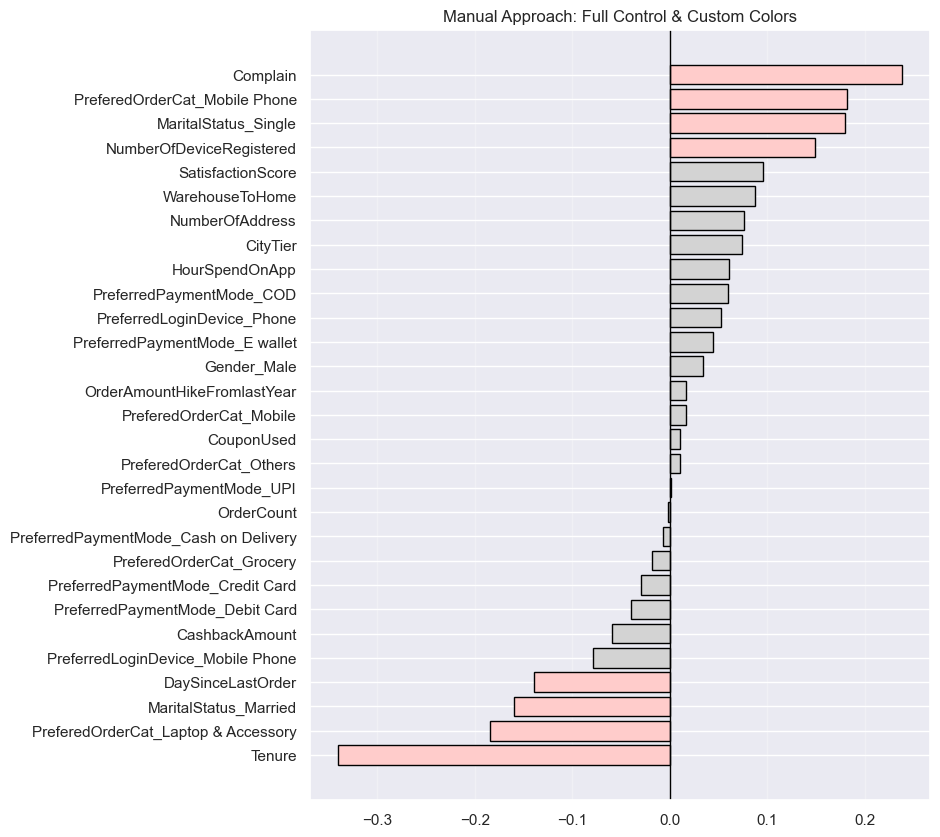

Generating pytimetk Correlation Funnel...


In [131]:
# --- 1. PREP DATA ---
# Drop ID and handle the 'Churn' target
df_for_corr = df_clean1.drop(columns=['CustomerID'])

# --- 2. THE MANUAL APPROACH (LEFT-STYLE LOGIC) ---
# We manually encode and plot to keep total control over colors/thresholds
df_encoded = pd.get_dummies(df_for_corr, drop_first=True)
corrs = df_encoded.corr()['Churn'].sort_values(ascending=True).drop('Churn')
colors = ['#ffcccb' if abs(val) > 0.1 else '#d3d3d3' for val in corrs.values]

plt.figure(figsize=(8, 10))
plt.barh(corrs.index, corrs.values, color=colors, edgecolor='black')
plt.title("Manual Approach: Full Control & Custom Colors")
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

# --- 3. THE PYTIMETK APPROACH (YOUR PROJECT LOGIC) ---
# pytimetk automates the binarization and correlation calculation
print("Generating pytimetk Correlation Funnel...")

# Note: Ensure 'Churn' is the target. pytimetk usually appends '__1' or '__Yes' 
# to the binarized target name depending on its value.
df_correlated = df_for_corr.binarize().correlate(target="Churn__1")

# This creates its own Plotly/Matplotlib interactive chart
df_correlated.plot_correlation_funnel(title="pytimetk Approach: Automated Binarization")

In [132]:
def calculate_iv(df, feature, target):
    # Binning numerical features into 5 quantiles
    if df[feature].dtype != 'object':
        df[feature] = pd.qcut(df[feature], q=5, duplicates='drop').astype(str)
    
    lst = []
    for val in df[feature].unique():
        lst.append({
            'Value': val,
            'All': df[df[feature] == val].count()[feature],
            'Good': df[(df[feature] == val) & (df[target] == 0)].count()[feature],
            'Bad': df[(df[feature] == val) & (df[target] == 1)].count()[feature]
        })
    
    data = pd.DataFrame(lst)
    data['Dist_Good'] = data['Good'] / data['Good'].sum()
    data['Dist_Bad'] = data['Bad'] / data['Bad'].sum()
    # Adding small epsilon to avoid division by zero
    data['WoE'] = np.log((data['Dist_Good'] + 0.0001) / (data['Dist_Bad'] + 0.0001))
    data['IV'] = (data['Dist_Good'] - data['Dist_Bad']) * data['WoE']
    return data['IV'].replace([np.inf, -np.inf], 0).sum()

iv_results = []
for col in df_clean1.drop(columns=['CustomerID', 'Churn']).columns:
    iv_results.append({'Column': col, 'IV': calculate_iv(df_clean1.copy(), col, 'Churn')})

iv_df = pd.DataFrame(iv_results).sort_values(by='IV', ascending=False)

def color_iv(val):
    if val >= 0.1: color = '#e2f0d9' # Light milky green
    elif val >= 0.02: color = '#fff2cc' # Light yellow
    else: color = '#f8d7da' # Light red
    return f'background-color: {color}; color: black;'

display(HTML("<h3>Information Value (IV) Rankings</h3>"))
display(iv_df.style.applymap(color_iv, subset=['IV']))

,Column,IV
0,Tenure,1.813079
8,PreferedOrderCat,0.286093
10,MaritalStatus,0.233354
16,DaySinceLastOrder,0.176302
7,NumberOfDeviceRegistered,0.156561
17,CashbackAmount,0.100917
11,NumberOfAddress,0.085716
3,WarehouseToHome,0.064108
9,SatisfactionScore,0.051814
4,PreferredPaymentMode,0.048355


In [133]:
#'Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear'

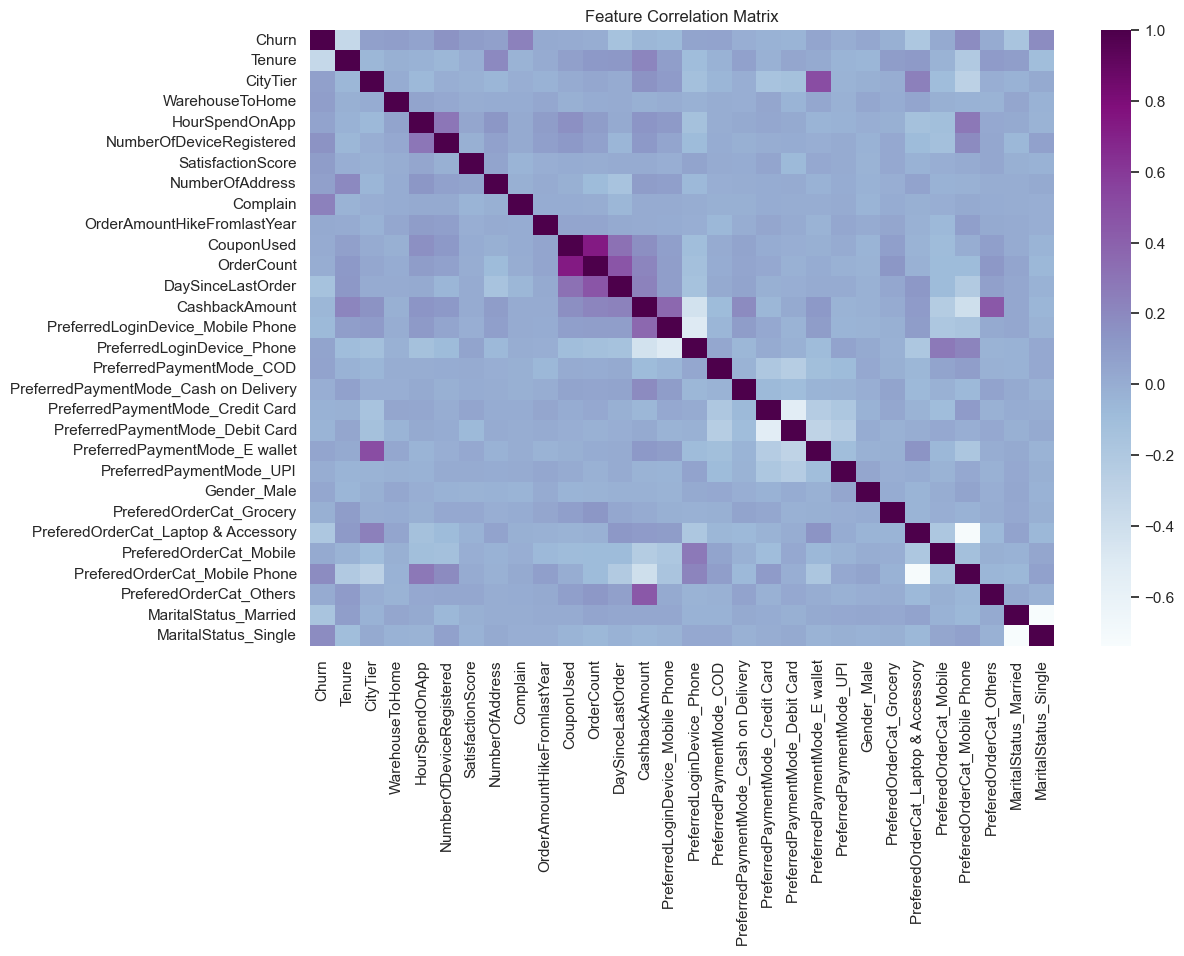

,V1,V2,Corr
311,CouponUsed,OrderCount,0.73247


In [134]:
# Encode for correlation
df_corr_ready = pd.get_dummies(df_clean1.drop(columns=['CustomerID']), drop_first=True)
corr_matrix = df_corr_ready.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='BuPu', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# Critical Insights Table
high_corr = corr_matrix.unstack().reset_index()
high_corr.columns = ['V1', 'V2', 'Corr']
high_corr = high_corr[(high_corr['Corr'] > 0.7) & (high_corr['V1'] != high_corr['V2'])].drop_duplicates(subset=['Corr'])

display(HTML("<h3>Critical Insights: High Multi-collinearity</h3>"))
display(high_corr)

In [135]:
# 1. Prepare numerical data
numeric_cols = df_clean1.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Churn']).dropna()

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(len(numeric_cols.columns))]

# 3. Sort the DataFrame FIRST
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 4. Styling logic with black text for all
def color_vif(val):
    color = '#f8d7da' if val > 5 else '#ffffff' # Light red if > 5, else white
    return f'background-color: {color}; color: black;'

display(HTML("<h3>VIF Table (Redundancy Check)</h3>"))
display(vif_data.style.applymap(color_vif, subset=['VIF']))

,Feature,VIF
12,CashbackAmount,36.334255
3,HourSpendOnApp,19.809198
8,OrderAmountHikeFromlastYear,16.654032
4,NumberOfDeviceRegistered,15.557459
10,OrderCount,5.751401
5,SatisfactionScore,5.586796
9,CouponUsed,4.541676
1,CityTier,4.428891
2,WarehouseToHome,4.255943
6,NumberOfAddress,4.117246


In [136]:
#'Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear'
df_clean1= df_clean1.drop(['Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear','CashbackAmount','CustomerID'], axis= 1)

In [137]:
# 1. Prepare numerical data (Excluding ID and Target)
numeric_cols = df_clean1.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Churn'], errors='ignore').dropna()

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(len(numeric_cols.columns))]

# 3. Sort the DataFrame FIRST
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 4. Styling logic
def color_vif(val):
    color = '#f8d7da' if val > 5 else '#ffffff' 
    return f'background-color: {color}; color: black;'

display(HTML("<h3>VIF Table (Redundancy Check)</h3>"))
display(vif_data.style.applymap(color_vif, subset=['VIF']))

,Feature,VIF
2,HourSpendOnApp,15.833200
3,NumberOfDeviceRegistered,12.818845
4,SatisfactionScore,5.180610
1,WarehouseToHome,4.065936
5,NumberOfAddress,3.995114
8,DaySinceLastOrder,3.518945
7,OrderCount,2.991823
0,Tenure,2.415014
6,Complain,1.383049


In [138]:
df_clean1.describe().round(2)

,Churn,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder
count,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00
mean,0.17,8.78,15.74,2.98,3.75,3.06,4.22,0.28,2.83,4.53
std,0.37,7.68,8.59,0.72,1.03,1.39,2.56,0.45,2.47,3.37
min,0.00,0.00,5.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00
25%,0.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,1.00,2.00
50%,0.00,8.00,14.00,3.00,4.00,3.00,3.00,0.00,2.00,3.00
75%,0.00,13.00,21.00,3.00,4.00,4.00,6.00,1.00,3.00,7.00
max,1.00,51.00,127.00,5.00,6.00,5.00,22.00,1.00,16.00,46.00


In [139]:
# suspecious: NumberOfAddress,OrderCount,DaySinceLastOrder,Tenure,WarehouseToHome

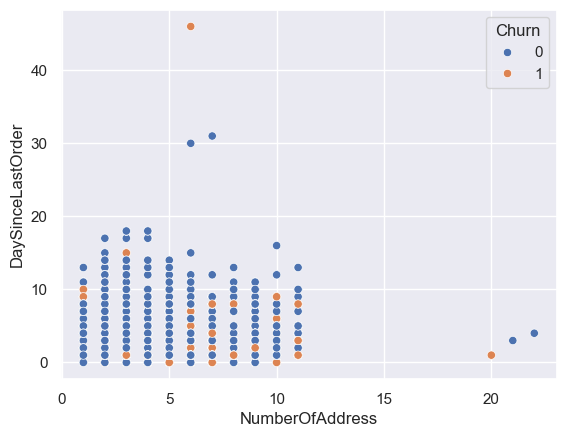

In [140]:
plt.figure()
sns.scatterplot(data= df_clean1, x='NumberOfAddress', y= 'DaySinceLastOrder', hue='Churn')
plt.show()

In [141]:
df_clean1.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'WarehouseToHome',
       'PreferredPaymentMode', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'OrderCount', 'DaySinceLastOrder'],
      dtype='object')

In [142]:
# clip tenure >31 to 31,
# clip WarehouseToHome>36 to 36
# NumberOfAddress > 15, drop
# DaySinceLastOrder >20 drop
# 1. Clipping (Winsorization)
# We assign the result back to the column to ensure changes are saved
df= df.dropna()
df['Tenure'] = df['Tenure'].clip(upper=31)
df['WarehouseToHome'] = df['WarehouseToHome'].clip(upper=36)
# 2. Filtering (Dropping rows)
# It is more efficient to filter the dataframe directly using boolean indexing
initial_count = len(df)
df = df[(df['NumberOfAddress'] <= 15) & (df['DaySinceLastOrder'] <= 20)]
# 3. Reset Index
df = df.reset_index(drop=True)
print(f"Rows dropped: {initial_count - len(df)}")

Rows dropped: 6


### Feature Engineering

In [143]:
df_clean2= df.drop(['Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear','CashbackAmount','CustomerID'], axis= 1)

In [144]:
# def drop_redundant_features(df):
#     """Drops the specified columns to prepare for model training."""
#     cols_to_drop = [
#         'Gender', 'CityTier', 'CouponUsed', 
#         'OrderAmountHikeFromlastYear', 'CashbackAmount', 'CustomerID'
#     ]
#     # errors='ignore' ensures the code doesn't crash if columns are already gone
#     return df.drop(columns=cols_to_drop, errors='ignore')

# # Application
# df_clean2 = drop_redundant_features(df)

### Preprocessing

In [145]:
# from sklearn.preprocessing import FunctionTransformer

# def consolidate_labels(df):
#     df = df.copy()
    
#     # 1. PreferredLoginDevice: Merge mobile types
#     df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(['Phone', 'Mobile Phone'], 'Phone')
    
#     # 2. PreferredPaymentMode: Group by payment architecture
#     df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
#         'E wallet': 'Debit Card', 'UPI': 'Debit Card', 'Debit Card': 'Debit Card',
#         'CC': 'Credit Card', 'Credit Card': 'Credit Card',
#         'Cash on Delivery': 'COD', 'COD': 'COD'
#     })
    
#     # 3. PreferedOrderCat: Group by product category
#     df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
#         'Mobile Phone': 'Phone', 'Mobile': 'Phone',
#         'Grocery': 'Others', 'Others': 'Others'
#     })
    
#     return df

# # Create the transformer
# label_merger = FunctionTransformer(consolidate_labels)

# # Apply it
# df_preprocessed = label_merger.transform(df_clean2)

In [146]:
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
# import pandas as pd

# # 1. Reuse your label consolidation function
# label_merger = FunctionTransformer(consolidate_labels)

# # 2. Identify remaining categorical columns
# cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']

# # 3. Create the ColumnTransformer for Encoding
# # sparse_output=False makes it easier to inspect the resulting DataFrame
# encoder = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
#     ], 
#     remainder='passthrough' # Keeps the numerical columns as they are
# )

# # 4. Combine into a single Pipeline
# preprocessing_pipeline = Pipeline(steps=[
#     ('label_merging', label_merger),
#     ('encoding', encoder)
# ])

# # Apply the pipeline
# X_processed = preprocessing_pipeline.fit_transform(df_clean2)

In [147]:
inputs =df.drop('Churn', axis=1)
target= df['Churn']
x_train, x_test, y_train, y_test= train_test_split(inputs, target,
                                                   random_state= 22, stratify= target, test_size= .2)

### Model selection

In [148]:
sns.reset_defaults()

[I 2026-02-22 10:49:47,924] A new study created in memory with name: no-name-310c495b-9c44-4857-9b2f-c0fc77e17877
[I 2026-02-22 10:49:48,053] Trial 0 finished with value: 0.7631812114659822 and parameters: {'max_depth': 6, 'learning_rate': 0.05389699858355412, 'min_child_weight': 9, 'subsample': 0.8334347744806224, 'colsample_bytree': 0.7106811493086267, 'reg_lambda': 0.681117943289206}. Best is trial 0 with value: 0.7631812114659822.
[I 2026-02-22 10:49:48,179] Trial 1 finished with value: 0.811177452843481 and parameters: {'max_depth': 7, 'learning_rate': 0.03979640042121092, 'min_child_weight': 3, 'subsample': 0.8790268738933897, 'colsample_bytree': 0.7630847837909442, 'reg_lambda': 0.07156014767040889}. Best is trial 1 with value: 0.811177452843481.
[I 2026-02-22 10:49:48,280] Trial 2 finished with value: 0.6623183507648995 and parameters: {'max_depth': 4, 'learning_rate': 0.015351020751725451, 'min_child_weight': 6, 'subsample': 0.7553733781701738, 'colsample_bytree': 0.7241808656

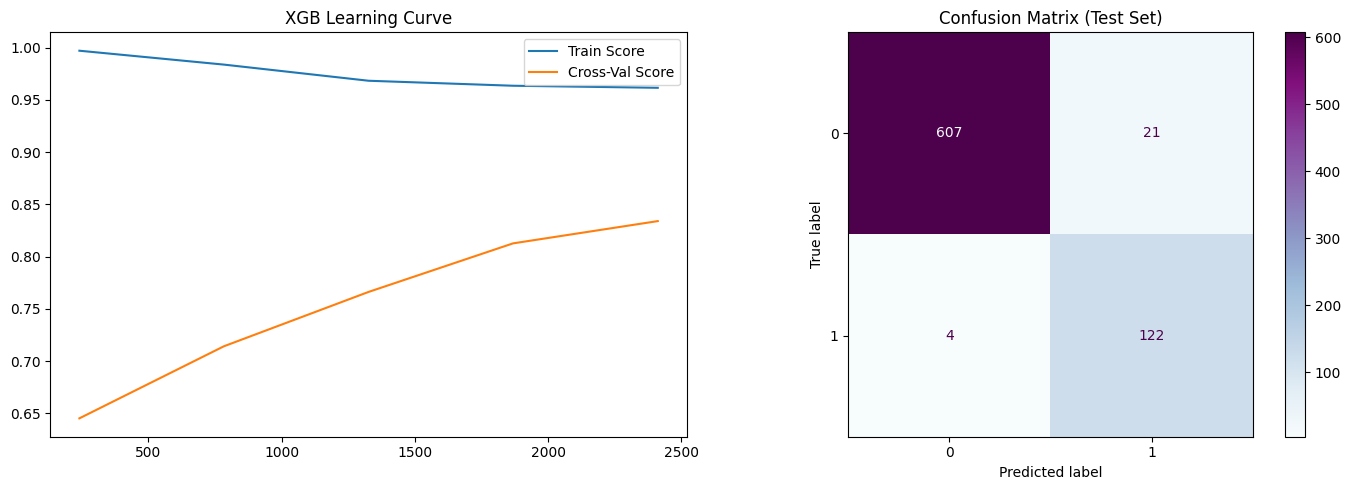

In [149]:
# --- 1. Custom Transformer & Function ---
class ColumnDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        cols = ['Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear','CashbackAmount','CustomerID']
        return X.drop(columns=cols, errors='ignore')

def consolidate_labels(df):
    df = df.copy()
    df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(['Phone', 'Mobile Phone'], 'Phone')
    df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
        'E wallet': 'Debit Card', 'UPI': 'Debit Card', 'CC': 'Credit Card', 'Cash on Delivery': 'COD'
    })
    df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
        'Mobile Phone': 'Phone', 'Mobile': 'Phone', 'Grocery': 'Others'
    })
    return df

# --- 2. Build Preprocessing Pipeline ---
final_cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']

full_preprocessing = Pipeline(steps=[
    ('drop_cols', ColumnDropper()),
    ('merge_labels', FunctionTransformer(consolidate_labels)),
    ('encode', ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), final_cat_cols)],
        remainder='passthrough'
    ))
])

# --- 3. Optuna Optimization ---
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# --- Updated Optuna Objective for XGBoost ---
def objective(trial):
    params = {
        # Allow slightly deeper trees but still limited
        'max_depth': trial.suggest_int('max_depth', 4, 8), 
        # Moderate learning rate
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        # min_child_weight prevents splits that only cover a few samples (reduces variance)
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Subsampling rows and columns to add randomness (reduces overfitting)
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        # L2 regularization to keep weights small
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 1.0, log=True),
        'scale_pos_weight': ratio,
        'random_state': 22,
        'eval_metric': 'logloss'
    }
    pipe = Pipeline([('prep', full_preprocessing), ('model', XGBClassifier(**params))])
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=22)
    return cross_val_score(pipe, x_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# --- 4. Final Fit and Plotting ---
best_pipe = Pipeline(steps=[
    ('prep', full_preprocessing), 
    ('xgb', XGBClassifier(**study.best_params, scale_pos_weight=ratio))
])
best_pipe.fit(x_train, y_train)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_pipe, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)

ax[0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
ax[0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
ax[0].set_title('XGB Learning Curve')
ax[0].legend()

# Confusion Matrix
y_pred = best_pipe.predict(x_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1], cmap='BuPu')
ax[1].set_title('Confusion Matrix (Test Set)')

plt.tight_layout()
plt.show()